# Task Intervention Timeline Analysis

이 노트북은 `task_intervention` 초단위 timeline 결과를 시각화합니다.

- event_active 정량 성능
- event type / robot state 분포
- episode별 timeline
- TP / FP / FN frame gallery
- bbox는 GT가 없어서 정답 IoU가 아니라 저장된 annotated frame과 gaze proxy로만 봅니다


In [3]:
from pathlib import Path
import json
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display

RESULT_JSON = Path('results/timeline_gemini-3.1-flash-lite-preview_audio_true_cap_true_fps4_tb0_prompt_center_moment_strict_fullrun_v1/timeline_results.json')
assert RESULT_JSON.exists(), f'Missing result file: {RESULT_JSON}'
data = json.loads(RESULT_JSON.read_text())
agg = data['aggregate']
samples = pd.DataFrame(data['samples'])
samples['pred_event_active'] = samples['prediction'].apply(lambda x: bool(x.get('event_active', False)) if isinstance(x, dict) else False)
samples['pred_event_type'] = samples['prediction'].apply(lambda x: x.get('event_type', 'none') if isinstance(x, dict) else 'none')
samples['pred_human_intent'] = samples['prediction'].apply(lambda x: x.get('human_intent', '') if isinstance(x, dict) else '')
samples['pred_robot_state'] = samples['prediction'].apply(lambda x: x.get('robot_state', 'unknown') if isinstance(x, dict) else 'unknown')
samples['pred_target_object'] = samples['prediction'].apply(lambda x: x.get('target_object', '') if isinstance(x, dict) else '')
samples['pred_confidence'] = samples['prediction'].apply(lambda x: float(x.get('confidence', 0.0)) if isinstance(x, dict) else 0.0)
WORKSPACE_ROOT = RESULT_JSON.resolve().parent.parent.parent

def resolve_result_path(p):
    if not isinstance(p, str) or not p:
        return None
    cand = Path(p)
    if cand.is_absolute():
        return cand
    for base in (WORKSPACE_ROOT, RESULT_JSON.parent, RESULT_JSON.parent.parent):
        resolved = (base / cand).resolve()
        if resolved.exists():
            return resolved
    return (WORKSPACE_ROOT / cand).resolve()

samples['frame_abs'] = samples['frame_path'].apply(resolve_result_path)
samples['category'] = np.select([samples['gt_positive'] & samples['pred_event_active'], (~samples['gt_positive']) & samples['pred_event_active'], samples['gt_positive'] & (~samples['pred_event_active'])], ['tp', 'fp', 'fn'], default='tn')
samples.head()


,episode_name,second_idx,clip_start_sec,clip_end_sec,center_sec,center_frame,gt_positive,prediction,bbox_px,gaze_xy,...,inference_time_sec,raw_response,pred_event_active,pred_event_type,pred_human_intent,pred_robot_state,pred_target_object,pred_confidence,frame_abs,category
0,task_intervention,0,0.0,1.0,0.5,8,False,"{'event_active': True, 'event_type': 'target_c...","[894, 877, 950, 936]","[749.0, 972.0]",...,3.7401,,True,target_correction,select the specific muffin indicated,awaiting_target_selection,muffin,0.95,/Users/choijuheonjuheon/DEV/KAIST_AI/robot_int...,fp
1,task_intervention,1,1.0,2.0,1.5,22,False,"{'event_active': False, 'event_type': 'other_c...",None,"[741.0, 844.0]",...,4.1270,,False,other_control,None,unknown,None,0.90,/Users/choijuheonjuheon/DEV/KAIST_AI/robot_int...,tn
2,task_intervention,2,2.0,3.0,2.5,38,False,"{'event_active': False, 'event_type': 'other_c...",None,"[779.0, 868.0]",...,4.5475,,False,other_control,None,unknown,None,0.90,/Users/choijuheonjuheon/DEV/KAIST_AI/robot_int...,tn
3,task_intervention,3,3.0,4.0,3.5,52,False,"{'event_active': True, 'event_type': 'target_r...","[638, 845, 739, 922]","[834.0, 838.0]",...,8.5156,,True,target_reference,The user wants the robot to pick up the cupcak...,awaiting_target_selection,cupcake,0.95,/Users/choijuheonjuheon/DEV/KAIST_AI/robot_int...,fp
4,task_intervention,4,4.0,5.0,4.5,68,True,"{'event_active': True, 'event_type': 'target_r...","[908, 922, 979, 993]","[838.0, 895.0]",...,4.4219,,True,target_reference,The user is identifying the target muffin for ...,awaiting_target_selection,muffin,0.95,/Users/choijuheonjuheon/DEV/KAIST_AI/robot_int...,tp


In [4]:
summary = pd.DataFrame([
    ('num_samples', agg['num_samples']),
    ('gt_positive_samples', agg['gt_positive_samples']),
    ('pred_positive_samples', agg['pred_positive_samples']),
    ('event_active_precision', agg['event_active_precision']),
    ('event_active_recall', agg['event_active_recall']),
    ('event_active_f1', agg['event_active_f1']),
    ('event_active_accuracy', agg['event_active_accuracy']),
    ('bbox_presence_on_gt_positive_rate', agg['bbox_presence_on_gt_positive_rate']),
    ('gaze_in_bbox_rate_on_gt_positive', agg['gaze_in_bbox_rate_on_gt_positive']),
    ('mean_inference_time_sec', agg['mean_inference_time_sec']),
    ('total_cost_usd', agg['total_cost_usd']),
], columns=['metric', 'value'])
display(summary)
display(pd.DataFrame([data['config']]))


,metric,value
0,num_samples,370.0000
1,gt_positive_samples,62.0000
2,pred_positive_samples,319.0000
3,event_active_precision,0.1944
4,event_active_recall,1.0000
5,event_active_f1,0.3255
6,event_active_accuracy,0.3054
7,bbox_presence_on_gt_positive_rate,1.0000
8,gaze_in_bbox_rate_on_gt_positive,0.2258
9,mean_inference_time_sec,4.5132


,model,video_fps,thinking_budget,caption,include_audio,prompt_variant,clip_duration,target_resolution
0,gemini-3.1-flash-lite-preview,4,0,True,True,center_moment_strict,1.0,"[256, 256]"


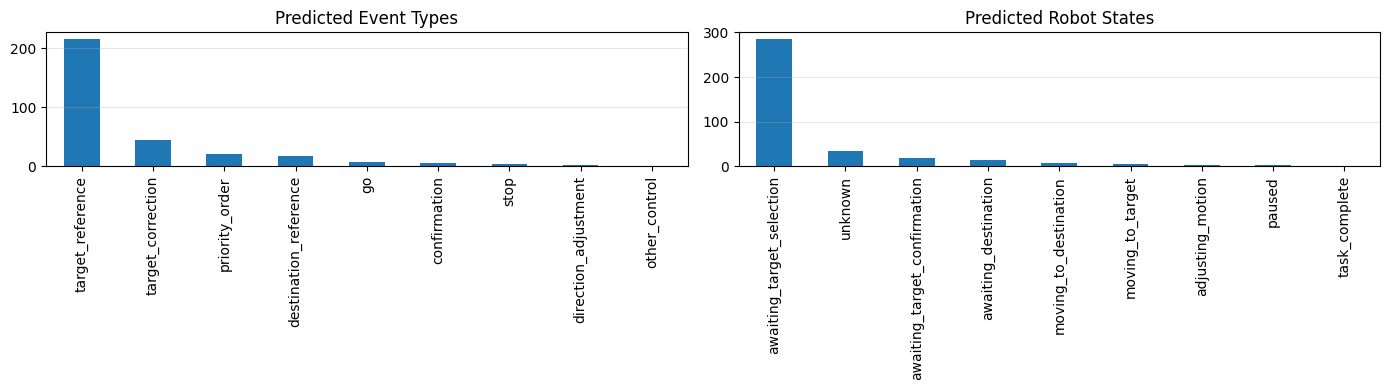

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
pd.Series(agg['pred_event_type_counts']).sort_values(ascending=False).plot(kind='bar', ax=axes[0], title='Predicted Event Types')
pd.Series(agg['robot_state_counts']).sort_values(ascending=False).plot(kind='bar', ax=axes[1], title='Predicted Robot States')
for ax in axes: ax.grid(axis='y', alpha=0.3)
plt.tight_layout()


,episode_name,pred_positive_seconds,gt_positive_seconds,pred_event_runs,gt_event_runs
0,task_intervention,19,7,3,3
1,task_intervention_10,22,4,4,2
2,task_intervention_11,26,3,2,3
3,task_intervention_12,11,3,2,3
4,task_intervention_13,18,3,1,1
5,task_intervention_14,18,3,3,3
6,task_intervention_2,24,6,4,2
7,task_intervention_3,13,3,1,2
8,task_intervention_4,30,4,2,2
9,task_intervention_5,28,3,2,2


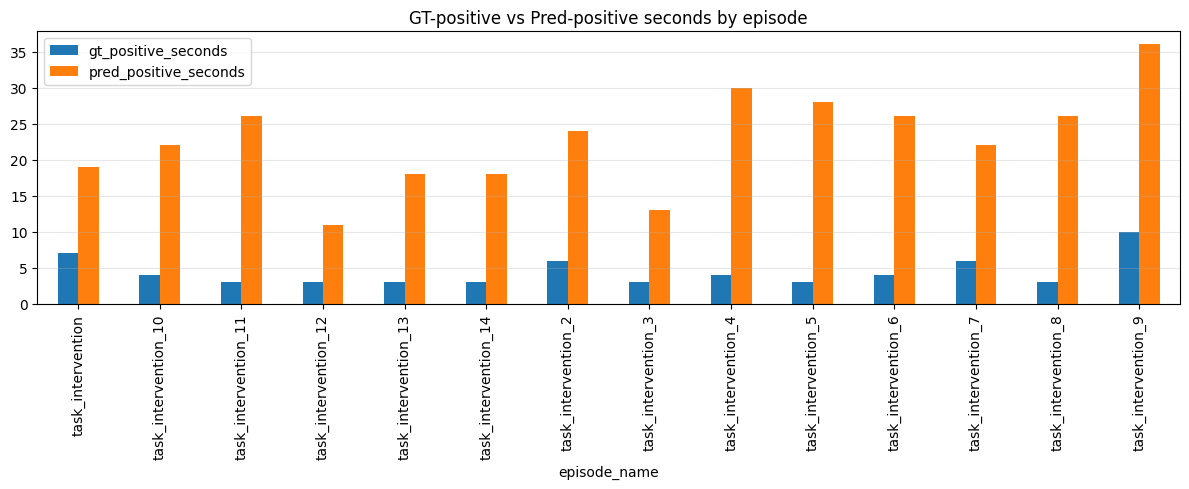

In [6]:
episode_counts = pd.DataFrame(agg['per_episode_timeline_counts']).sort_values('episode_name')
display(episode_counts)
fig, ax = plt.subplots(figsize=(12, 5))
episode_counts.set_index('episode_name')[['gt_positive_seconds', 'pred_positive_seconds']].plot(kind='bar', ax=ax)
ax.set_title('GT-positive vs Pred-positive seconds by episode')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()


In [7]:
def plot_episode_timeline(episode_name):
    df = samples[samples['episode_name'] == episode_name].sort_values('second_idx').copy()
    if df.empty:
        raise ValueError(f'Unknown episode: {episode_name}')
    secs = df['second_idx'].to_numpy()
    gt = df['gt_positive'].astype(int).to_numpy()
    pred = df['pred_event_active'].astype(int).to_numpy()
    conf = df['pred_confidence'].to_numpy()
    fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True, gridspec_kw={'height_ratios':[1, 1]})
    axes[0].step(secs, gt, where='mid', label='GT positive', linewidth=2)
    axes[0].step(secs, pred, where='mid', label='Pred active', linewidth=2)
    axes[0].set_ylim(-0.1, 1.2)
    axes[0].legend()
    axes[0].set_title(f'{episode_name} | event timeline')
    axes[0].grid(alpha=0.3)
    type_codes = {name: idx for idx, name in enumerate(sorted(df['pred_event_type'].unique()))}
    axes[1].scatter(secs[df['pred_event_active']], [type_codes[t] for t in df.loc[df['pred_event_active'], 'pred_event_type']], c=conf[df['pred_event_active']], cmap='viridis', s=60)
    axes[1].set_yticks(list(type_codes.values()))
    axes[1].set_yticklabels(list(type_codes.keys()))
    axes[1].set_xlabel('Second index')
    axes[1].set_title('Predicted event type at active seconds')
    axes[1].grid(alpha=0.3)
    plt.tight_layout()
    display(df[['second_idx', 'gt_positive', 'pred_event_active', 'pred_event_type', 'pred_human_intent', 'pred_robot_state', 'pred_target_object', 'gaze_in_bbox']])


In [8]:
def show_gallery(episode_name=None, category='fp', max_items=12, cols=4):
    df = samples.copy()
    if episode_name is not None:
        df = df[df['episode_name'] == episode_name]
    df = df[df['category'] == category].sort_values(['episode_name', 'second_idx']).head(max_items)
    if df.empty:
        print('No samples')
        return
    rows = math.ceil(len(df) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 3.4 * rows))
    axes = np.array(axes).reshape(-1)
    for ax, (_, row) in zip(axes, df.iterrows()):
        img = Image.open(row['frame_abs'])
        ax.imshow(img)
        ax.axis('off')
        ax.set_title(f"{row['episode_name']} s={int(row['second_idx'])} | {row['pred_event_type']}")
    for ax in axes[len(df):]:
        ax.axis('off')
    plt.tight_layout()
    display(df[['episode_name', 'second_idx', 'category', 'gt_positive', 'pred_event_active', 'pred_event_type', 'pred_human_intent', 'pred_robot_state', 'pred_target_object', 'gaze_in_bbox']])


,second_idx,gt_positive,pred_event_active,pred_event_type,pred_human_intent,pred_robot_state,pred_target_object,gaze_in_bbox
48,0,False,True,target_reference,Requesting the robot to pick up the indicated ...,awaiting_target_selection,muffin,False
49,1,False,True,target_reference,Requesting the robot to pick up a specific muf...,awaiting_target_selection,muffin,False
50,2,False,True,target_reference,Request the robot to pick up the specific muffin.,awaiting_target_selection,muffin,False
51,3,False,False,other_control,None,unknown,None,None
52,4,False,True,target_reference,The user wants the robot to pick up the indica...,awaiting_target_selection,cupcake,False
53,5,True,True,target_reference,The user is selecting a specific muffin for th...,awaiting_target_selection,muffin,True
54,6,False,True,target_reference,The user is indicating which muffin they want ...,awaiting_target_selection,muffin,False
55,7,False,True,target_reference,Indicate the destination for the robot to plac...,awaiting_destination,yellow basket,False
56,8,False,True,target_reference,The user wants the robot to pick up the indica...,awaiting_target_selection,muffin,False
57,9,False,True,target_reference,The user wants the robot to pick up the indica...,awaiting_target_selection,muffin,False


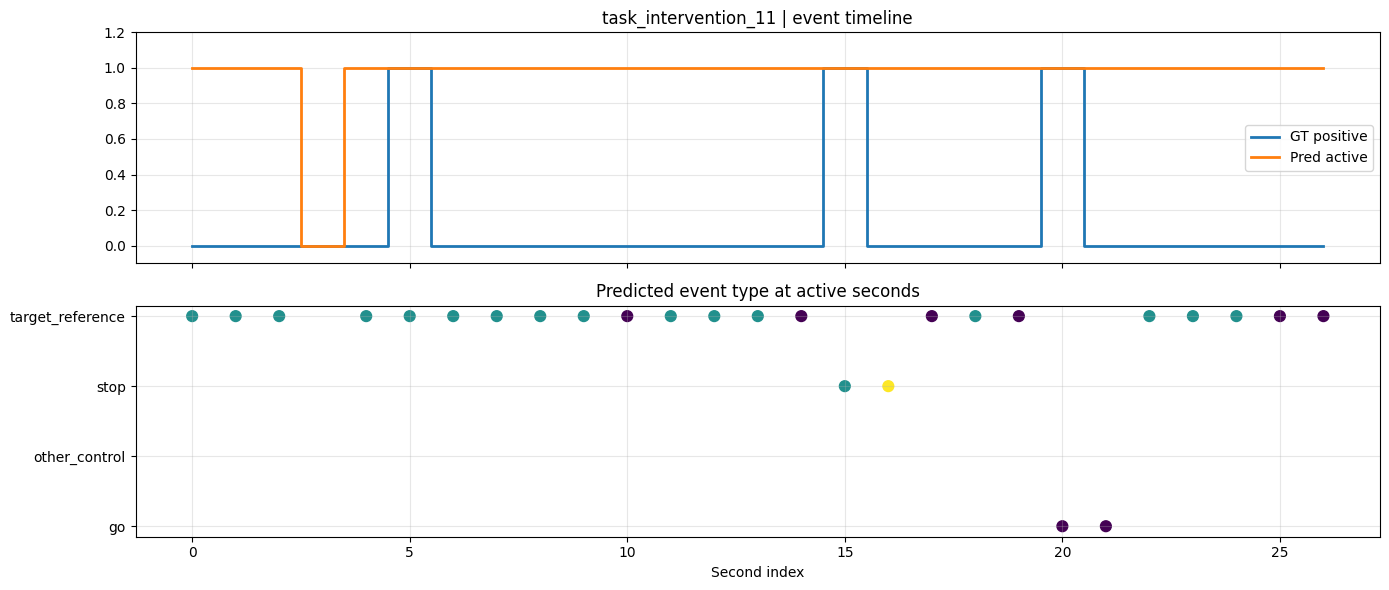

In [9]:
# Example usage
plot_episode_timeline('task_intervention_11')


FileNotFoundError: [Errno 2] No such file or directory: '/Users/choijuheonjuheon/DEV/KAIST_AI/robot_interaction/aria_keyframe_labeling/results/results/timeline_gemini-3.1-flash-lite-preview_audio_true_cap_true_fps4_tb0_prompt_center_moment_strict_fullrun_v1/frames/task_intervention_11/sec_000.jpg'

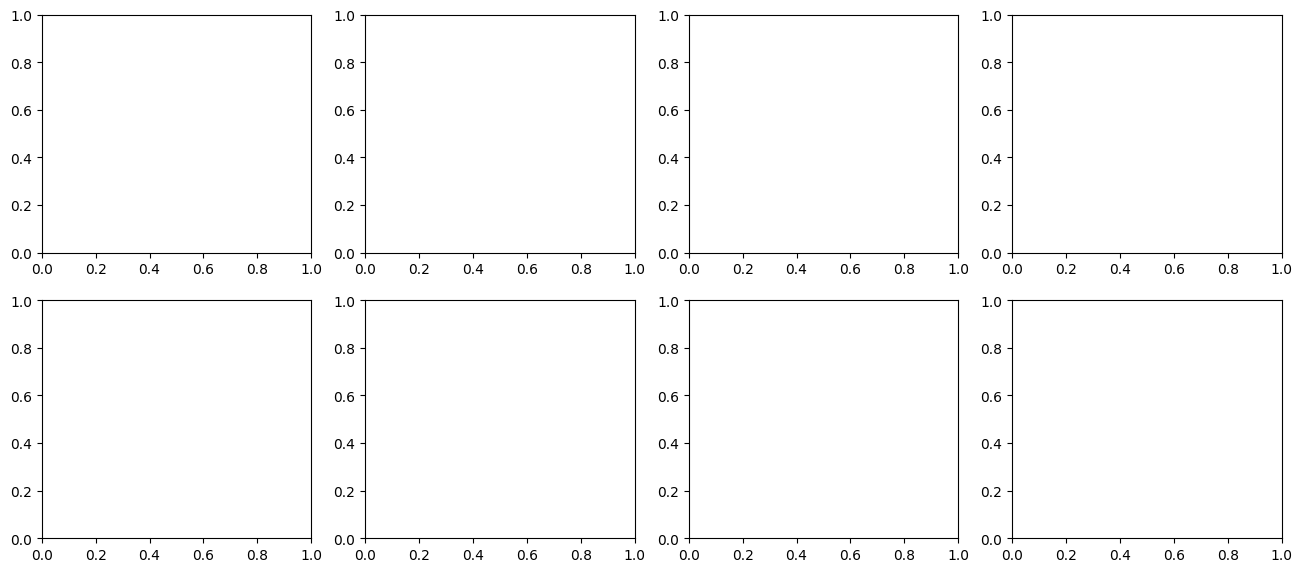

In [10]:
# False positives to inspect
show_gallery(episode_name='task_intervention_11', category='fp', max_items=8)


FileNotFoundError: [Errno 2] No such file or directory: '/Users/choijuheonjuheon/DEV/KAIST_AI/robot_interaction/aria_keyframe_labeling/results/results/timeline_gemini-3.1-flash-lite-preview_audio_true_cap_true_fps4_tb0_prompt_center_moment_strict_fullrun_v1/frames/task_intervention_11/sec_005.jpg'

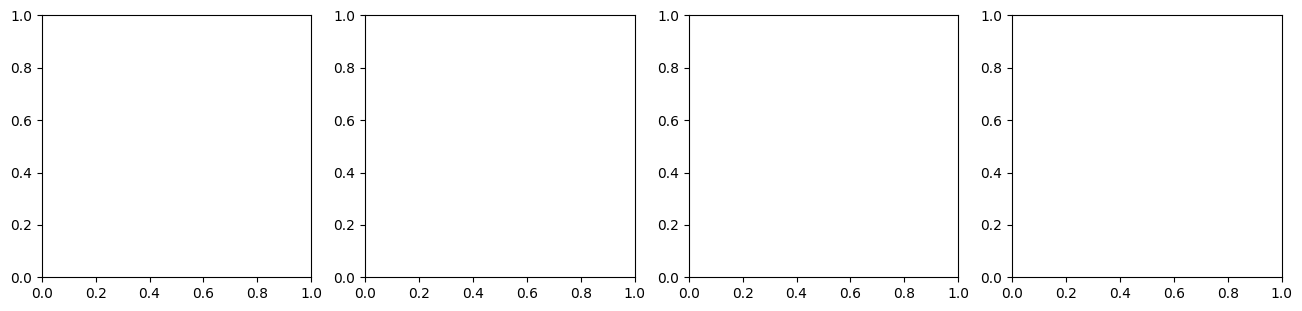

In [11]:
# True positives to inspect
show_gallery(episode_name='task_intervention_11', category='tp', max_items=8)
